### Some math for the Fourier SIAC filter and FBP

Define the unit box as
$$
B_1(x) = \chi_{[-1/2,\,1/2)} =
\begin{cases}
1, & x \in [-1/2,\,1/2),\\
0, & \text{else}.
\end{cases}
$$

Higher–order splines are defined by repeated self–convolution,
$$
B_{n+1}(x) = (B_1 * B_n)(x)
= \underbrace{\chi_{[-1/2,\,1/2)} * \chi_{[-1/2,\,1/2)} * \cdots * \chi_{[-1/2,\,1/2)}}_{n+1\ \text{times}}.
$$

The Fourier transform of the first spline is
$$
\widehat B_1(\xi)
= \mathcal{F}[B_1](\xi)
= \int_{\mathbb R} \chi_{[-1/2,\,1/2)}(x)\, e^{-i2\pi\xi x}\,dx,
\qquad \xi\in\mathbb R.
$$

Since the support of $B_1$ is $[-1/2,1/2)$, this reduces to
$$
\widehat B_1(\xi)
= \int_{-1/2}^{1/2} e^{-i2\pi\xi x}\,dx
= \left[\frac{e^{-i2\pi\xi x}}{-i2\pi\xi}\right]_{-1/2}^{1/2}
= \frac{e^{-i\pi\xi}-e^{i\pi\xi}}{-i2\pi\xi}
= \frac{\sin(\pi\xi)}{\pi\xi}.
$$

Hence
$$
\widehat B_1(\xi) = \operatorname{sinc}(\xi),
\qquad
\operatorname{sinc}(\xi) := \frac{\sin(\pi\xi)}{\pi\xi}.
$$

By the convolution theorem, repeated convolution in physical space corresponds to multiplication in Fourier space. Therefore,
$$
\widehat B_n(\xi)
= \bigl(\widehat B_1(\xi)\bigr)^n
= \operatorname{sinc}(\xi)^n,
\qquad n \ge 1.
$$

In particular,
$$
\widehat B_2(\xi) = \operatorname{sinc}(\xi)^2,
\qquad
\widehat B_3(\xi) = \operatorname{sinc}(\xi)^3.
$$

Taking the inverse Fourier transform yields the first three centered splines:
$$
B_1(x) = \chi_{[-1/2,\,1/2)}(x),
$$
$$
B_2(x) =
\begin{cases}
1 - |x|, & |x| \le 1,\\
0, & \text{else},
\end{cases}
$$
$$
B_3(x) =
\begin{cases}
\frac{1}{2}(2 - |x|)^2, & 1 \le |x| < 2,\\[4pt]
\frac{3}{4} - x^2, & |x| < 1,\\
0, & \text{else}.
\end{cases}
$$


### Fourier SIAC filter with the FBP

**Regular FBP**
\begin{align*}
    \text{FBP} = A^* \mathcal{F}^{-1}\big[ |\omega|W(\omega) \mathcal{F}[\cdot] \big]
\end{align*}

Where $A^*$ is the adjoint to the X-ray transform, $\mathcal{F}$ is the Fourier transform and $W$ is a window (e.g. Shepp-Logan or Hann).

**FBP with SIAC**
\begin{align*}
    \text{FBP} = A^* \mathcal{F}^{-1}\big[ \underbrace{|\omega|W(\omega)}_{\text{standard FBP}} \underbrace{\widehat{S}(\omega)}_{\text{SIAC}} \mathcal{F}[\cdot] \big]
\end{align*}

A **sepereable** 2D frequency filter has the form:
$$
    \widehat{S}(\omega_x, \omega_y) = \widehat{S}_x(\omega_x) \cdot \widehat{S}_y(\omega_y)
$$
so it can be interpreted as applying a 1D filter in the $x$-direction and a 1D filter in $y$-direction (in the Fourier domain).

We **pad** the image before FFT-based filtering to avoid edge artifacts. FFT-based convolution assumes the input is periodic, meaning the left/right and top/bottom edges are implicitly “wrapped together”. Padding creates a buffer region so the effective convolution support does not reach the artificial periodic boundary, and we then crop back to the original field of view.

The padding itself only has to be slightly larger than the effective support of the SIAC kernel (radius). Since it is a B-spline of order $n$, it has support of width $n+1$, with the shifts $\gamma = 0, \ldots, r$ spanning a range of length $\sim r$. Thus we pad a distance of
$$
    R_{\text{pad}} \approx \frac{r+n+1}{2}
$$
in grid voxels (approximately the radius of the kernel).

### Fourier Form of Filter

The Fourier Form of the filter consisting of $r+1$ B-Splines of order $n$ is 
$$\sigma(\omega_n) = \left(\frac{\sin(\omega_n/2)}{\omega_n/2}\right)^n\left(c_0 + 2\sum_{\gamma = 1}^r\, c_\gamma \cos(\gamma\omega_n))\right)$$

### Plotting the SIAC as a ODL Fourier filter

In [67]:
import numpy as np
import pandas as pd
import odl
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [68]:
from matplotlib.lines import Line2D
from src.siac_fourier import siac_filter_odl, siac_cgam_fourier

In [69]:
# Create a function to return the ODL Fourier filters
def fbp_filters(norm_freq, filter_type, frequency_scaling):
    filter_type_in = filter_type    # Add this for error message
    if callable(filter_type):
        filt = filter_type(norm_freq)
    else:   # add else here for string-based call (e.g. "hann")
        filter_type = str(filter_type).lower()
        if filter_type == 'ram-lak':
            filt = np.copy(norm_freq)
        elif filter_type == 'shepp-logan':
            filt = norm_freq * np.sinc(norm_freq / (2 * frequency_scaling))
        elif filter_type == 'cosine':
            filt = norm_freq * np.cos(norm_freq * np.pi / (2 * frequency_scaling))
        elif filter_type == 'hamming':
            filt = norm_freq * (
                0.54 + 0.46 * np.cos(norm_freq * np.pi / (frequency_scaling)))
        elif filter_type == 'hann':
            filt = norm_freq * (
                np.cos(norm_freq * np.pi / (2 * frequency_scaling)) ** 2)
        else:
            raise ValueError('unknown `filter_type` ({})'
                            ''.format(filter_type_in))

    indicator = (norm_freq <= frequency_scaling)
    filt *= indicator
    return filt
    


**We begin by using the SIAC kernel as a window**

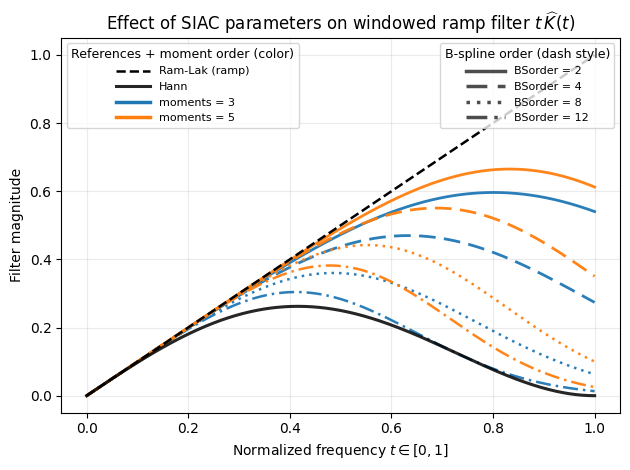

In [73]:
t = np.linspace(0.0, 1.0, 2001)

moments_list = [2, 4]
BSorder_list = [2, 4, 8, 12]

# Reference filters
H_ramp = fbp_filters(t, filter_type="Ram-Lak", frequency_scaling=1.0)
H_best = fbp_filters(t, filter_type="Hann", frequency_scaling=1.0)

# Style maps
colors = {2: "C0", 4: "C1", 6:"C2"}  # same color for same moments

# Use explicit dash patterns to make legend styles unmistakable
dash_map = {
    2: None,              # solid
    4: (6, 3),            # dashed
    8: (1, 2),            # dotted
    12: (6, 2, 1, 2),      # dash-dot
}

# Plot SIAC windowed ramp for each combo
for m in moments_list:
    for p in BSorder_list:
        H = siac_filter_odl(m, p, include_ramp=True)(t)
        (line,) = plt.plot(
            t, H,
            color=colors[m],
            linewidth=2.0 if p in (2, 4) else 1.8,
            alpha=0.95
        )
        # apply dash pattern (solid if None)
        if dash_map[p] is not None:
            line.set_dashes(dash_map[p])

# Plot references (store handles)
(ref_ramp,) = plt.plot(t, H_ramp, color="k", linewidth=1.8, linestyle="--", label="Ram-Lak (ramp)")
(ref_best,) = plt.plot(t, H_best, color="k", linewidth=2.2, linestyle="-", alpha=0.85, label=f"Hann")

plt.xlabel("Normalized frequency $t \\in [0,1]$")
plt.ylabel("Filter magnitude")
plt.title("Effect of SIAC parameters on windowed ramp filter $t\\,\\widehat K(t)$")
plt.grid(True, alpha=0.25)

ax = plt.gca()

# --- Left legend: references + moments (colors) ---
handles_left = [
    ref_ramp,
    ref_best,
    Line2D([0], [0], color=colors[2], lw=2.5, linestyle="-", label=f"moments = 3"),
    Line2D([0], [0], color=colors[4], lw=2.5, linestyle="-", label=f"moments = 5"),
]
leg1 = ax.legend(
    handles=handles_left,
    title="References + moment order (color)",
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    handlelength=3.0
)
ax.add_artist(leg1)

# --- Right legend: BSorder (dash style) ---
handles_right = []
for p in BSorder_list:
    h = Line2D([0], [0], color="0.3", lw=2.5, linestyle="-", label=f"BSorder = {p}")
    if dash_map[p] is not None:
        h.set_dashes(dash_map[p])
    handles_right.append(h)

ax.legend(
    handles=handles_right,
    title="B-spline order (dash style)",
    loc="upper right",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    handlelength=3.5
)

plt.tight_layout()
plt.show()



**Now the physical space SIAC filter as a fourier filter**

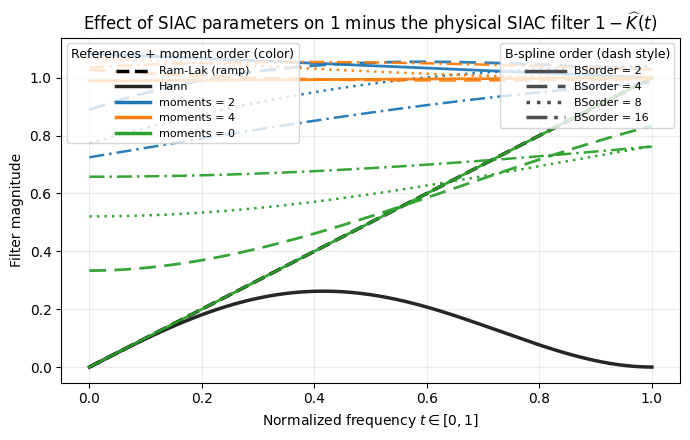

In [71]:
from src.siac_modal import centered_cardinal_bspline, siac_cgam


def siac_spline_filter(moments, BSorder):
    cgam = siac_cgam(moments, BSorder)
    R = len(cgam) - 1
    gammas = np.arange(-R, R + 1)       # shifts
    B = centered_cardinal_bspline(BSorder)
    
    def kernel(x):
        x = np.asarray(x, dtype=float)
        out = np.zeros_like(x, dtype=float)
        for c, xg in zip(cgam, gammas):
            out += c * B(x - xg)
        return out
    
    def filt(t):
        t = np.asarray(t, dtype=float)
        t = np.clip(t, 0.0, 1.0)
        
        W = kernel(t)
        return 1 - W
    return filt
            

t = np.linspace(0.0, 1.0, 2001)

moments_list = [0, 2, 4]
BSorder_list = [2, 4, 8, 16]

# Style maps
colors = {2: "C0", 4: "C1", 0: "C2"}  # same color for same moments

# Use explicit dash patterns to make legend styles unmistakable
dash_map = {
    2: None,              # solid
    4: (6, 3),            # dashed
    8: (1, 2),            # dotted
    16: (6, 2, 1, 2),      # dash-dot
}

plt.figure(figsize=(7, 4.5))

# Plot references (store handles)
(ref_ramp,) = plt.plot(t, H_ramp, color="k", linewidth=2.5, linestyle="--", label="Ram-Lak (ramp)")
(ref_best,) = plt.plot(t, H_best, color="k", linewidth=2.5, linestyle="-", alpha=0.85, label=f"Hann")

# Plot SIAC windowed ramp for each combo
for m in moments_list:
    for p in BSorder_list:
        H = siac_spline_filter(m, p)(t)
        (line,) = plt.plot(
            t, H,
            color=colors[m],
            linewidth=2.0 if p in (2, 4) else 1.8,
            alpha=0.95
        )
        # apply dash pattern (solid if None)
        if dash_map[p] is not None:
            line.set_dashes(dash_map[p])
            
plt.xlabel("Normalized frequency $t \\in [0,1]$")
plt.ylabel("Filter magnitude")
plt.title("Effect of SIAC parameters on 1 minus the physical SIAC filter $1 - \\widehat K(t)$")
plt.grid(True, alpha=0.25)

ax = plt.gca()

# --- Left legend: references + moments (colors) ---
handles_left = [
    ref_ramp,
    ref_best,
    Line2D([0], [0], color=colors[2], lw=2.5, linestyle="-", label="moments = 2"),
    Line2D([0], [0], color=colors[4], lw=2.5, linestyle="-", label="moments = 4"),
    Line2D([0], [0], color=colors[0], lw=2.5, linestyle="-", label="moments = 0"),

]
leg1 = ax.legend(
    handles=handles_left,
    title="References + moment order (color)",
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    handlelength=3.0
)
ax.add_artist(leg1)

# --- Right legend: BSorder (dash style) ---
handles_right = []
for p in BSorder_list:
    h = Line2D([0], [0], color="0.3", lw=2.5, linestyle="-", label=f"BSorder = {p}")
    if dash_map[p] is not None:
        h.set_dashes(dash_map[p])
    handles_right.append(h)

ax.legend(
    handles=handles_right,
    title="B-spline order (dash style)",
    loc="upper right",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    handlelength=3.5
)

plt.tight_layout()
plt.show()
